In [1]:
#BiocManager::install("EnsDb.Mmusculus.v79")

Bioconductor version 3.12 (BiocManager 1.30.10), R 4.0.4 (2021-02-15)

Installing package(s) 'EnsDb.Mmusculus.v79'

Old packages: 'cli', 'DelayedArray', 'desc', 'dplyr', 'farver', 'ggforce',
  'isoband', 'lubridate', 'magick', 'pillar', 'pkgload', 'ps', 'RcppArmadillo',
  'rvest', 'segmented', 'tibble', 'tidyr', 'tinytex', 'waldo', 'boot',
  'cluster', 'MASS', 'mgcv'



In [1]:
library(edgeR)
library(ggplot2)
library(ggrepel)
library(reshape2)
library(scales)
library(gridExtra)
library(EnsDb.Mmusculus.v79)  # v75 for hg19

Loading required package: limma

Loading required package: ensembldb

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:gridExtra’:

    combine


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    Filter, Find, Map, Position, Reduce, anyDuplicated, append,
    as.data.frame, basename, cbind, colnames, dirname, do.call,
    duplicated, eval, evalq, get, grep, grepl, intersect, is.unsorted,
    lapply, mapply, match, mget, order, paste, pmax, pmax.int, pmin,
    pmin.int, rank, rbind, rownames, sapply, setdiff, sort, table,
    tapply, union, unique, unsplit, which.max, which.min


Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The following objects are masked

In [2]:
setwd("~/Dropbox (MIT)/MVH_Code/brq/bd205/")

In [11]:
df = read.table("data/raw_counts.tsv", skip = 1, header = TRUE, row.names=1)
df = df[,6:dim(df)[2]]
head(df)

,v2_results.star.633_E7_v2_sgNTC2_DMSO_rep1_Aligned.sortedByCoord.out.bam,v2_results.star.633_E7_v2_sgNTC2_DMSO_rep2_Aligned.sortedByCoord.out.bam,v2_results.star.633_E7_v2_sgNTC2_DMSO_rep3_Aligned.sortedByCoord.out.bam,v2_results.star.633_E7_v2_sgNTC2_DMSO_rep4_Aligned.sortedByCoord.out.bam,v2_results.star.633_E7_v2_sgNTC2_BRQ_rep1_Aligned.sortedByCoord.out.bam,v2_results.star.633_E7_v2_sgNTC2_BRQ_rep2_Aligned.sortedByCoord.out.bam,v2_results.star.633_E7_v2_sgNTC2_BRQ_rep3_Aligned.sortedByCoord.out.bam,v2_results.star.633_E7_v2_sgNTC2_BRQ_rep4_Aligned.sortedByCoord.out.bam,v2_results.star.633_E7_v2_sgSPI1.1_DMSO_rep1_Aligned.sortedByCoord.out.bam,v2_results.star.633_E7_v2_sgSPI1.1_DMSO_rep2_Aligned.sortedByCoord.out.bam,⋯,v2_results.star.633_E7_v2_sgSPI1.1_BRQ_rep3_Aligned.sortedByCoord.out.bam,v2_results.star.633_E7_v2_sgSPI1.1_BRQ_rep4_Aligned.sortedByCoord.out.bam,v2_results.star.633_E7_v2_sgSPI1.2_DMSO_rep1_Aligned.sortedByCoord.out.bam,v2_results.star.633_E7_v2_sgSPI1.2_DMSO_rep2_Aligned.sortedByCoord.out.bam,v2_results.star.633_E7_v2_sgSPI1.2_DMSO_rep3_Aligned.sortedByCoord.out.bam,v2_results.star.633_E7_v2_sgSPI1.2_DMSO_rep4_Aligned.sortedByCoord.out.bam,v2_results.star.633_E7_v2_sgSPI1.2_BRQ_rep1_Aligned.sortedByCoord.out.bam,v2_results.star.633_E7_v2_sgSPI1.2_BRQ_rep2_Aligned.sortedByCoord.out.bam,v2_results.star.633_E7_v2_sgSPI1.2_BRQ_rep3_Aligned.sortedByCoord.out.bam,v2_results.star.633_E7_v2_sgSPI1.2_BRQ_rep4_Aligned.sortedByCoord.out.bam
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSMUSG00000102693.1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
ENSMUSG00000064842.1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
ENSMUSG00000051951.5,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
ENSMUSG00000102851.1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
ENSMUSG00000103377.1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
ENSMUSG00000104017.1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [12]:
colnames(df) = gsub("v2_results.star.633_E7_v2_", "", gsub("_Aligned.sortedByCoord.out.bam", "", colnames(df)))


potential_rownames = as.character(sapply(rownames(df), function(x) strsplit(x, '[.]')[[1]][1]))
df = df[!(duplicated(potential_rownames)),]
rownames(df) = potential_rownames[!(duplicated(potential_rownames))]                           
annotations_orgDb <- AnnotationDbi::select(EnsDb.Mmusculus.v79, # database
                                     keys = rownames(df) ,  # data to use for retrieval
                                     columns = c("SYMBOL"), # information to retreive for given data
                                     keytype = "GENEID") # type of data given in 'keys' argument
annotations_orgDb = annotations_orgDb[!duplicated(annotations_orgDb$SYMBOL),]

df = df[annotations_orgDb$GENEID,]  # you lose a few genes here but not many
rownames(df) = annotations_orgDb$SYMBOL


head(df)

,sgNTC2_DMSO_rep1,sgNTC2_DMSO_rep2,sgNTC2_DMSO_rep3,sgNTC2_DMSO_rep4,sgNTC2_BRQ_rep1,sgNTC2_BRQ_rep2,sgNTC2_BRQ_rep3,sgNTC2_BRQ_rep4,sgSPI1.1_DMSO_rep1,sgSPI1.1_DMSO_rep2,⋯,sgSPI1.1_BRQ_rep3,sgSPI1.1_BRQ_rep4,sgSPI1.2_DMSO_rep1,sgSPI1.2_DMSO_rep2,sgSPI1.2_DMSO_rep3,sgSPI1.2_DMSO_rep4,sgSPI1.2_BRQ_rep1,sgSPI1.2_BRQ_rep2,sgSPI1.2_BRQ_rep3,sgSPI1.2_BRQ_rep4
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
RP23-271O17.1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Gm26206,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Xkr4,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
RP23-317L18.1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
RP23-317L18.4,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
RP23-317L18.3,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [13]:
conds = c(rep("sgNTC_DMSO", 4), rep("sgNTC_BRQ", 4), rep("sg1_DMSO", 4),
rep("sg1_BRQ", 4), rep("sg2_DMSO", 4), rep("sg2_BRQ", 4))

In [14]:
d0 <- DGEList(df)
d0 <- calcNormFactors(d0)
cutoff <- 5
drop <- which(apply(cpm(d0), 1, max) < cutoff)
d <- d0[-drop, ]
dim(d) # number of genes left

[1] 11235    24

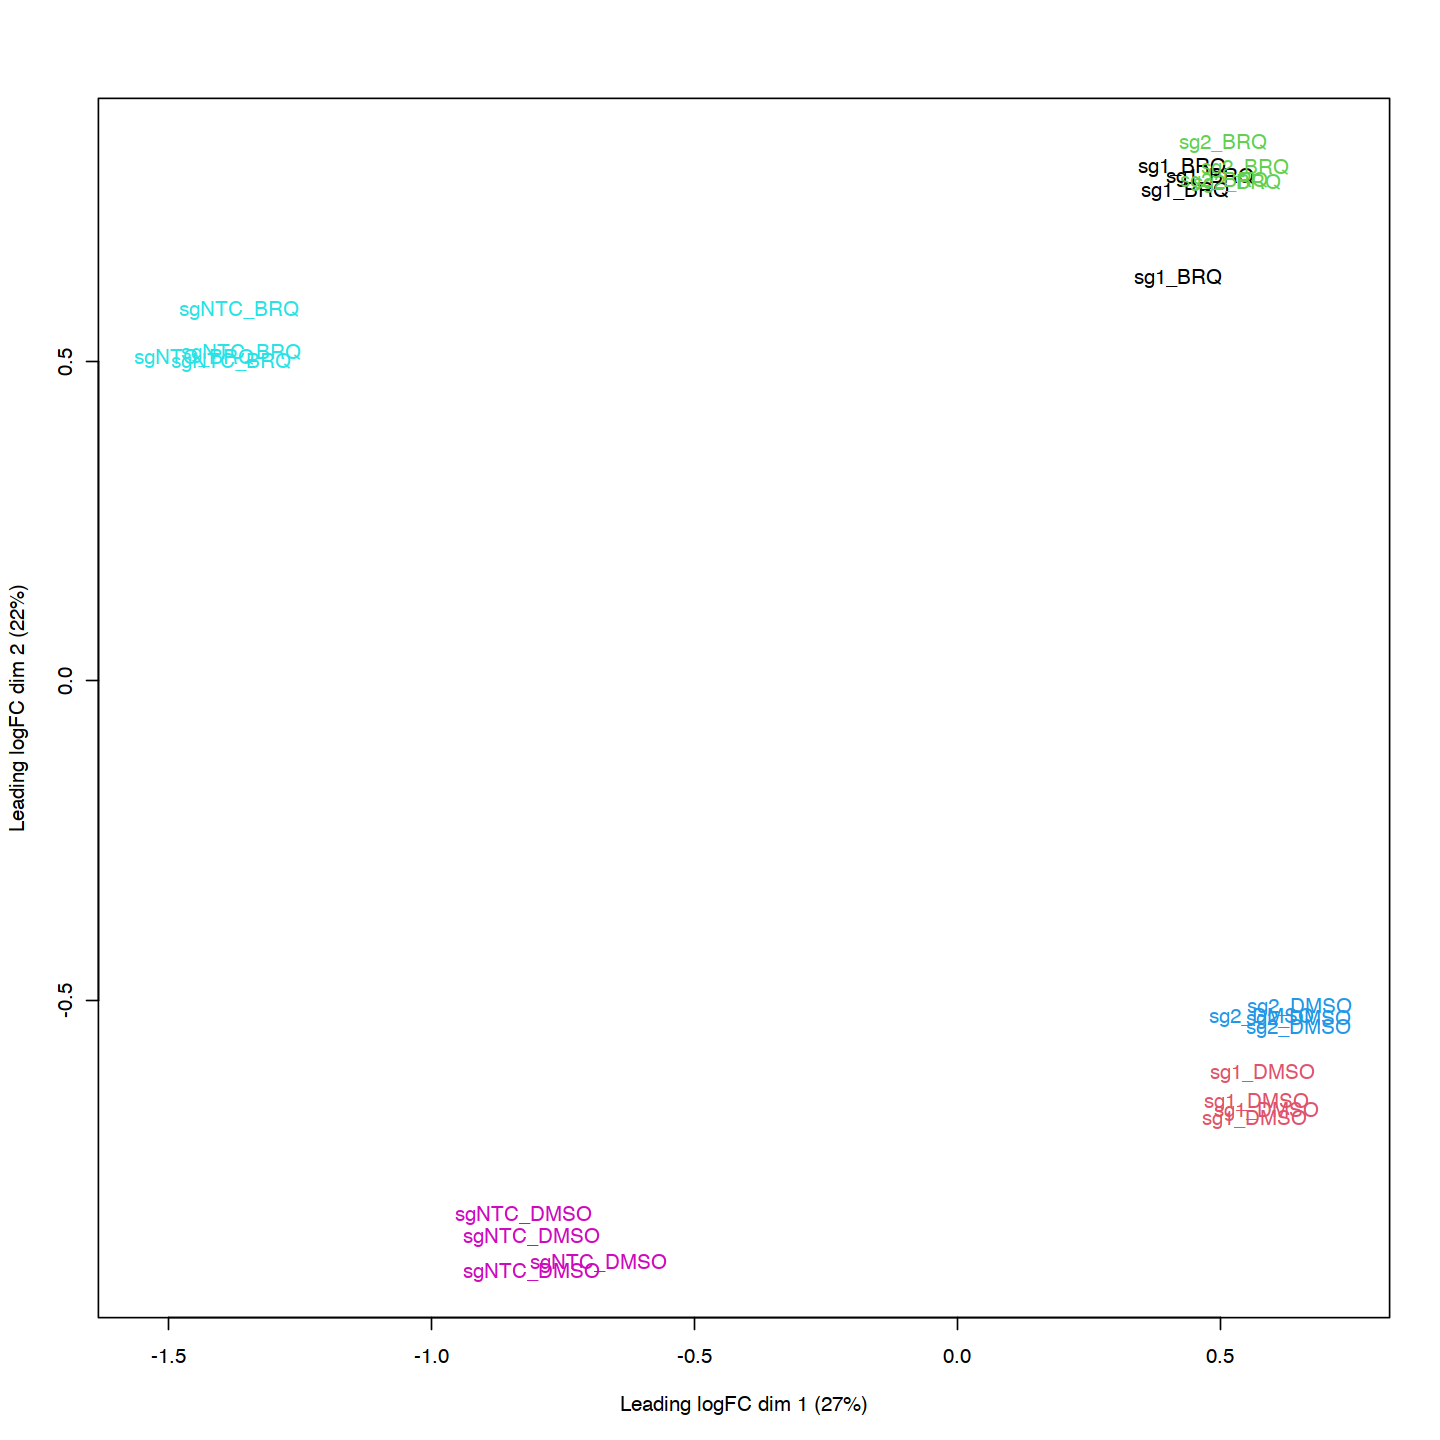

In [15]:
conds_new = as.character(conds)
options(repr.plot.width=12, repr.plot.height=12)
plotMDS(d, col = as.numeric(as.factor(conds_new)), labels = conds_new)

,condssg1_BRQ,condssg1_DMSO,condssg2_BRQ,condssg2_DMSO,condssgNTC_BRQ,condssgNTC_DMSO
Mrpl15,7.2633360,7.308058,7.149248,7.085059,7.1161851,7.4597295
RP23-34E15.5,2.6916675,3.212230,3.073570,3.041691,3.1136166,2.8045453
Lypla1,7.6212900,7.794460,7.489806,7.915985,7.4498527,7.7473353
RP24-426M1.3,2.9255128,3.758544,2.755192,3.553149,3.1361822,4.1133908
Tcea1,6.0081052,6.404733,5.928629,6.477488,6.0398593,6.8902980
Gm6104,0.4250863,1.681678,0.867355,1.673172,-0.1615635,0.9901789


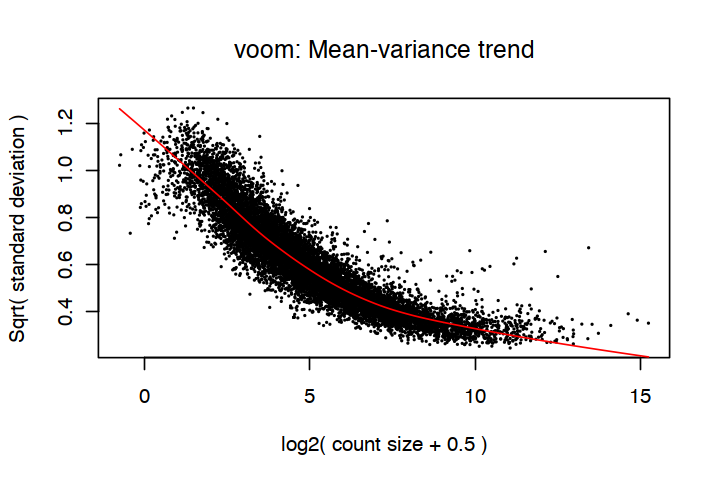

In [16]:
options(repr.plot.width =6, repr.plot.height=4)

mm <- model.matrix(~0 + conds)
y <- voom(d, mm, plot = T)
fit <- lmFit(y, mm)
head(coef(fit))

In [17]:
norm_data = y$E
write.csv(norm_data, "220724_bd205_norm_expr.csv", quote=F)

In [18]:
process_res = function(res) {
    tmp <- contrasts.fit(fit, res)
    tmp <- eBayes(tmp)
    res <- topTable(tmp, sort.by = "P", n = Inf)
    
    res["gene"] = rownames(res)
    res["nlogpval"] = -log10(res$adj.P.Val)
    res["label"] = ""
    res_up = res[res$logFC > 0,]
    res_up[order(-res_up$nlogpval),][1:50,]$label = res_up[order(-res_up$nlogpval),][1:50,]$gene
    res_down = res[res$logFC < 0,]
    res_down[order(-res_down$nlogpval),][1:50,]$label = res_down[order(-res_down$nlogpval),][1:50,]$gene
    res = rbind(res_up, res_down)
    res = res[order(-res$t),]
    return(res)
}

In [10]:
process_conds = function(res, cond1, cond2, write_outputs=FALSE) {
    #print(head(res))
   # if(write_outputs) write.csv(res, paste("../output/210310_bd178_", cond1, '_', cond2, ".csv", sep=''), quote=F)
    print(res[res$gene %in% c("Spi1", "Cebpa", "Cdkn1a", "Itgam"),])
    
    options(repr.plot.width=8, repr.plot.height=6)
    p = ggplot(as.data.frame(res), aes(x=logFC, y=nlogpval, label=label)) + 
    geom_point() + geom_text_repel() + geom_vline(xintercept = 0, color="gray") + ggtitle(paste(cond1, "vs", cond2))
   # if(write_outputs) ggsave(paste("../output/210310_bd178_", cond1, '_', cond2, ".pdf", sep=''), width=8, height=6)
    print(p)
}

                        logFC  AveExpr         t      P.Value    adj.P.Val
ENSMUSG00000023067 -0.1145573 3.575926 -0.538551 5.933709e-01 8.051421e-01
ENSMUSG00000034957 -0.3981731 3.439537 -1.224541 2.283651e-01 4.955497e-01
ENSMUSG00000030786 -2.6672729 0.369627 -3.602856 9.075743e-04 1.191589e-02
ENSMUSG00000002111 -3.1148502 2.846300 -8.997470 6.502255e-11 9.380483e-09
                            B   gene   nlogpval label
ENSMUSG00000023067 -6.6793697 Cdkn1a 0.09412748      
ENSMUSG00000034957 -5.8136741  Cebpa 0.30491278      
ENSMUSG00000030786 -0.7373009  Itgam 1.92387341      
ENSMUSG00000002111 14.4980108   Spi1 8.02777482  Spi1


Warning message:
"ggrepel: 40 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


,logFC,AveExpr,t,P.Value,adj.P.Val,B,gene,nlogpval,label
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
ENSMUSG00000022225,5.8314716,3.2449668,9.4464491,1.801973e-11,3.082404e-09,13.882079,Cma1,8.51111043,Cma1
ENSMUSG00000022797,0.9485281,5.9462663,8.8056921,1.133596e-10,1.508187e-08,13.959033,Tfrc,7.82154494,Tfrc
ENSMUSG00000027556,5.6881597,2.6066270,8.6748206,1.660778e-10,2.030475e-08,11.896339,Car1,7.69240246,
ENSMUSG00000031162,3.5997940,2.9530125,6.4113816,1.627455e-07,8.773333e-06,7.059503,Gata1,5.05683537,
ENSMUSG00000051839,3.3274838,1.3167396,5.4465708,3.367334e-06,1.196453e-04,4.131274,Gypa,3.92210442,
ENSMUSG00000054191,2.1570190,0.7640852,3.1926652,2.847497e-03,2.824849e-02,-1.633123,Klf1,1.54900473,
ENSMUSG00000000782,1.6057587,1.0088801,2.9169665,5.932289e-03,4.856318e-02,-2.312176,Tcf7,1.31369288,
ENSMUSG00000005763,1.3155530,0.9209274,1.8659264,6.986695e-02,2.493759e-01,-4.184630,Cd247,0.60314546,
ENSMUSG00000022952,0.4102576,2.7275581,1.4061643,1.678859e-01,4.189800e-01,-5.453220,Runx1,0.37780669,


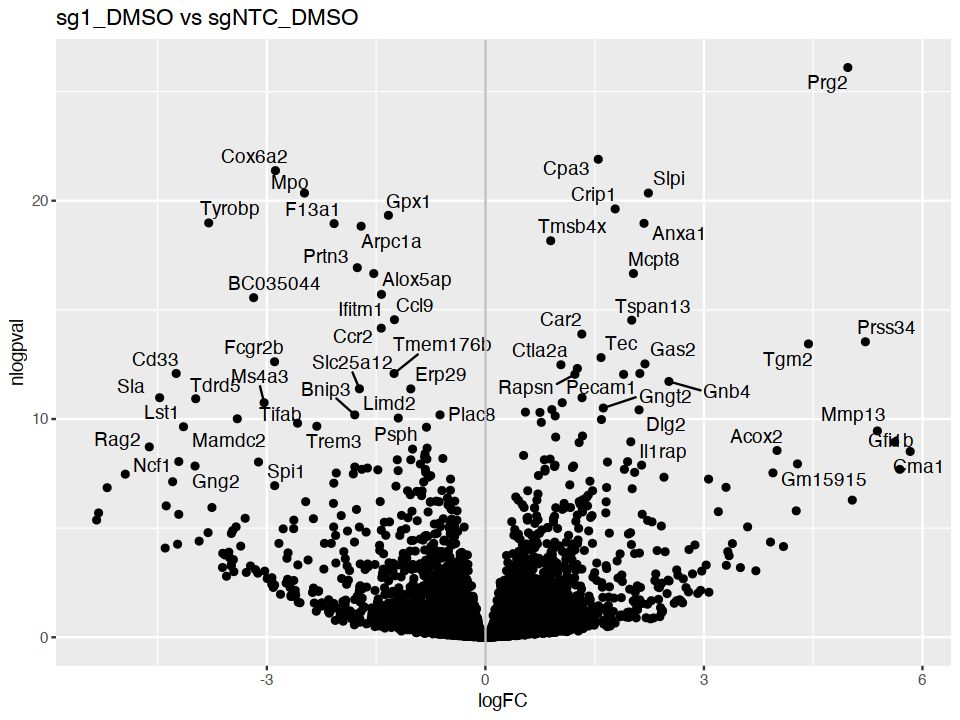

In [44]:
cond1 = "sg1_DMSO"
cond2 = "sgNTC_DMSO"
res <- process_res(makeContrasts(paste("conds", cond1, " - ", "conds", cond2, sep=""), 
                                 levels = colnames(coef(fit))))
process_conds(res, cond1, cond2, write_outputs=T)

res[which(res$gene %in% c("Gypa", "Tfrc", "Klf1", "Cma1", "Car1", "Gata1", "Runx1", "Spi1", "Cd274",
"Cd247", 'Tcf7', "Hoxa9", "Meis1", "Hbb-bt")),]


                        logFC  AveExpr         t     P.Value  adj.P.Val
ENSMUSG00000034957  1.0364926 3.439537  3.152519 0.003174596 0.01487192
ENSMUSG00000002111  1.0012509 2.846300  2.355022 0.023845892 0.07321300
ENSMUSG00000030786  1.8495290 0.369627  2.212624 0.033071941 0.09363997
ENSMUSG00000023067 -0.6078274 3.575926 -2.197362 0.034229100 0.09625628
                           B   gene nlogpval label
ENSMUSG00000034957 -1.851297  Cebpa 1.827633      
ENSMUSG00000002111 -3.357553   Spi1 1.135412      
ENSMUSG00000030786 -3.572377  Itgam 1.028539      
ENSMUSG00000023067 -3.949942 Cdkn1a 1.016571      


Warning message:
"ggrepel: 73 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


,logFC,AveExpr,t,P.Value,adj.P.Val,B,gene,nlogpval,label
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
ENSMUSG00000022225,2.0868004,3.2449668,13.1052033,1.358497e-15,2.904759e-13,25.1764814,Cma1,12.5368899,Cma1
ENSMUSG00000027556,1.8270357,2.6066270,10.9710654,2.802450e-13,3.107086e-11,20.0744611,Car1,10.5076467,
ENSMUSG00000031162,1.4069406,2.9530125,5.6525959,1.763356e-06,2.686313e-05,5.0291929,Gata1,4.5708434,
ENSMUSG00000073940,3.3745157,0.5999648,4.7053703,3.385440e-05,3.444117e-04,1.0137546,Hbb-bt,3.4629221,
ENSMUSG00000016496,3.0431281,0.6049398,4.4900660,6.550607e-05,6.010496e-04,0.9820756,Cd274,3.2210897,
ENSMUSG00000051839,1.2872671,1.3167396,4.3070692,1.141687e-04,9.546481e-04,1.1752373,Gypa,3.0201567,
ENSMUSG00000005763,2.0944383,0.9209274,4.1920410,1.613960e-04,1.270594e-03,0.6839830,Cd247,2.8959931,
ENSMUSG00000020160,0.5217837,3.9615522,2.4742046,1.798463e-02,5.903179e-02,-3.5573991,Meis1,1.2289140,
ENSMUSG00000002111,1.0012509,2.8462995,2.3550223,2.384589e-02,7.321300e-02,-3.3575534,Spi1,1.1354118,


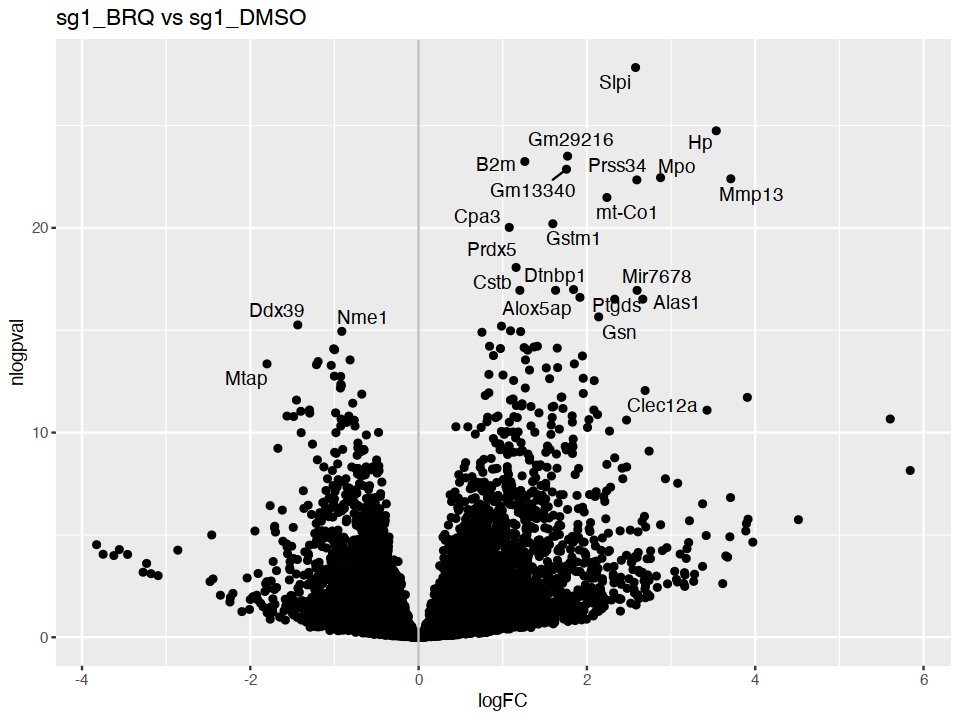

In [45]:
cond1 = "sg1_BRQ"
cond2 = "sg1_DMSO"
res <- process_res(makeContrasts(paste("conds", cond1, " - ", "conds", cond2, sep=""), 
                                 levels = colnames(coef(fit))))
process_conds(res, cond1, cond2, write_outputs=T)
res[which(res$gene %in% c("Gypa", "Tfrc", "Hbb-bt", "Cma1", "Car1", "Gata1",
"Runx1", "Spi1", "Cd247", "Hoxa9", "Meis1", "Cd274")),]

                         logFC  AveExpr           t      P.Value    adj.P.Val
ENSMUSG00000030786  3.31803221 0.369627  9.88785000 5.233006e-12 3.041748e-10
ENSMUSG00000002111  1.35509635 2.846300  9.50770154 1.515580e-11 7.924694e-10
ENSMUSG00000034957  0.60290668 3.439537  2.11599221 4.102610e-02 1.116469e-01
ENSMUSG00000023067 -0.01478691 3.575926 -0.06638347 9.474242e-01 9.699434e-01
                           B   gene   nlogpval label
ENSMUSG00000030786 16.490716  Itgam 9.51687671      
ENSMUSG00000002111 16.279309   Spi1 9.10101750      
ENSMUSG00000034957 -4.367458  Cebpa 0.95215318      
ENSMUSG00000023067 -6.581305 Cdkn1a 0.01325361      


Warning message:
"ggrepel: 67 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


,logFC,AveExpr,t,P.Value,adj.P.Val,B,gene,nlogpval,label
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
ENSMUSG00000002111,1.3550964,2.8462995,9.5077015,1.515580e-11,7.924694e-10,16.279309,Spi1,9.10101750,
ENSMUSG00000073940,2.9846056,0.5999648,6.5725672,9.830887e-08,2.022595e-06,7.193163,Hbb-bt,5.69409105,
ENSMUSG00000020160,0.6102858,3.9615522,3.3123244,2.051976e-03,1.016985e-02,-1.850635,Meis1,1.99268549,
ENSMUSG00000022952,0.7762936,2.7275581,2.7102983,1.006985e-02,3.739961e-02,-2.935837,Runx1,1.42713288,
ENSMUSG00000016496,1.6874931,0.6049398,2.1470242,3.830481e-02,1.058776e-01,-3.644430,Cd274,0.97519587,
ENSMUSG00000022225,0.8792533,3.2449668,1.0162117,3.160231e-01,4.937912e-01,-4.931925,Cma1,0.30645667,
ENSMUSG00000031162,0.3398183,2.9530125,0.4473636,6.571792e-01,7.906264e-01,-5.481841,Gata1,0.10202870,
ENSMUSG00000030775,0.2181553,-0.8821090,0.2294940,8.197288e-01,8.963183e-01,-5.216401,Trat1,0.04753774,
ENSMUSG00000027556,0.1147684,2.6066270,0.1217421,9.037516e-01,9.448635e-01,-5.265036,Car1,0.02463094,


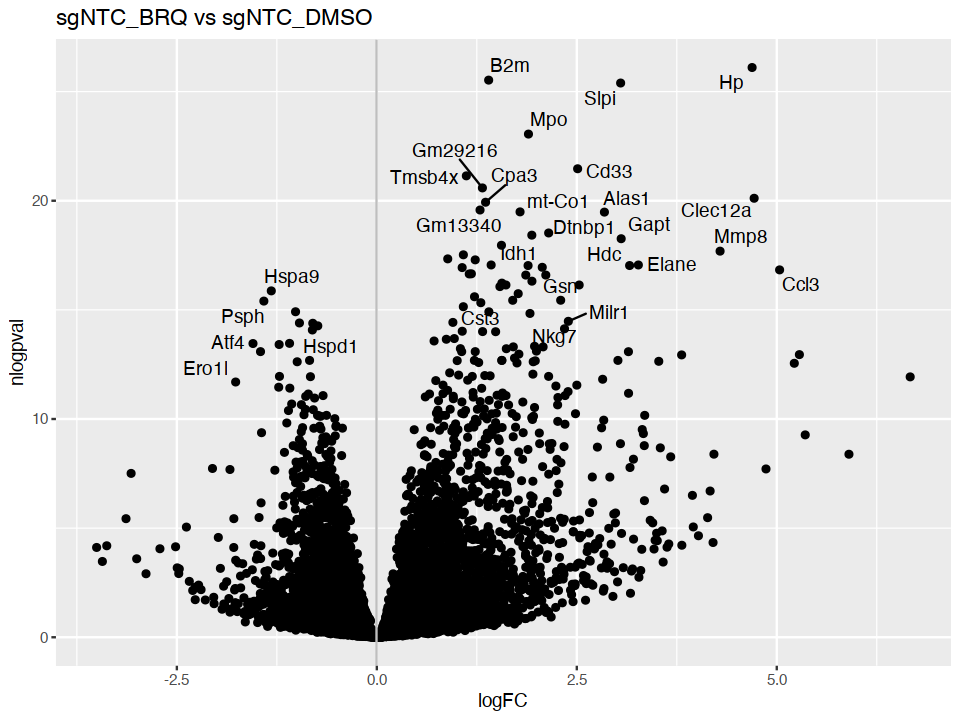

In [80]:
cond1 = "sgNTC_BRQ"
cond2 = "sgNTC_DMSO"
res <- process_res(makeContrasts(paste("conds", cond1, " - ", "conds", cond2, sep=""), 
                                 levels = colnames(coef(fit))))
process_conds(res, cond1, cond2, write_outputs=T)
res[which(res$gene %in% c("Gypa", "Tfrc", "Hbb-bt", "Cma1", "Car1", "Gata1", 
"Runx1", "Spi1", "Cd247","Meis1", "Hoxa9", "Ryr1", "Cd274", "Trat1")),]

                        logFC  AveExpr         t      P.Value    adj.P.Val
ENSMUSG00000034957  0.6383195 3.439537  2.260674 2.965300e-02 7.408742e-02
ENSMUSG00000030786 -0.8177438 0.369627 -1.407147 1.675965e-01 2.833791e-01
ENSMUSG00000023067 -0.7223847 3.575926 -2.715312 9.943679e-03 3.035065e-02
ENSMUSG00000002111 -2.1135993 2.846300 -7.237132 1.250964e-08 2.336823e-07
                           B   gene  nlogpval label
ENSMUSG00000034957 -4.311291  Cebpa 1.1302555      
ENSMUSG00000030786 -4.962254  Itgam 0.5476321      
ENSMUSG00000023067 -3.254688 Cdkn1a 1.5178319      
ENSMUSG00000002111  9.750732   Spi1 6.6313741      


Warning message:
"ggrepel: 66 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


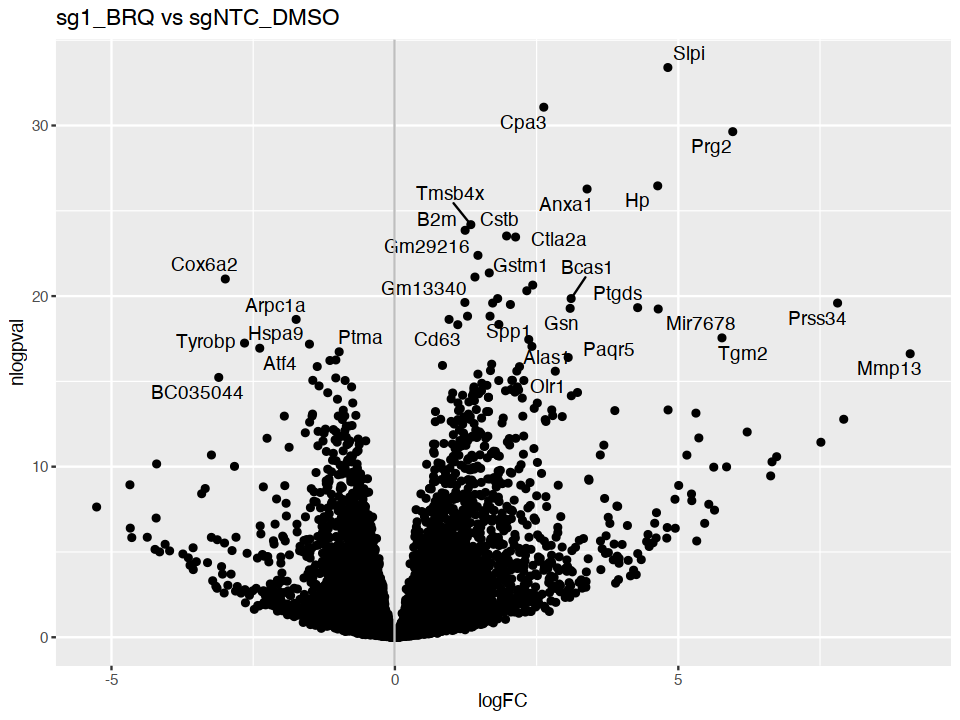

In [49]:
cond1 = "sg1_BRQ"
cond2 = "sgNTC_DMSO"
res <- process_res(makeContrasts(paste("conds", cond1, " - ", "conds", cond2, sep=""), 
                                 levels = colnames(coef(fit))))
process_conds(res, cond1, cond2, write_outputs=T)

## Compare everything to Untreated sgNTC

In [51]:
require(ComplexHeatmap)
require(circlize)
require(RColorBrewer)

Loading required package: ComplexHeatmap

Loading required package: grid

ComplexHeatmap version 2.10.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite:
Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
  genomic data. Bioinformatics 2016.

The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


Loading required package: circlize

circlize version 0.4.13
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize im

In [52]:
all_conds <- unique(conds)
all_conds

[1] "sgNTC_DMSO" "sgNTC_BRQ"  "sg1_DMSO"   "sg1_BRQ"    "sg2_DMSO"  
[6] "sg2_BRQ"

In [53]:
cond_to_res <- list()
for (cond1 in all_conds) {
    if (cond1 == "sgNTC_DMSO") next
    cond2 == "sgNTC_DMSO"
    res <- process_res(makeContrasts(
        paste("conds", cond1, " - ", "conds", cond2, sep = ""),
        levels = colnames(coef(fit))))
    cond_to_res[[cond1]] <- res
}

In [54]:
# get pvals, only take those where at least one is significant 
pvals = as.data.frame(cond_to_res$sgNTC_BRQ[order(cond_to_res$sgNTC_BRQ$gene),]$gene)
pvals = cbind(pvals, 0)
cond_list = c("genes", "sgNTC_DMSO")
for (cond1 in all_conds) {
    if (cond1 == "sgNTC_DMSO") next
    cond_list = c(cond_list, cond1)  # add to column names
    pvals = cbind(pvals, cond_to_res[[cond1]][order(cond_to_res[[cond1]]$gene),]$adj.P.Val)
}
colnames(pvals) = cond_list
pvals = pvals[!(pvals$genes %in% c("", "Mtcp1", "Csnk2a1")),]
rownames(pvals) = pvals$genes
pvals = pvals[,2:dim(pvals)[2]]
sig_genes = rownames(pvals[apply(pvals[,2:6], 1, min) < 0.05,])
length(sig_genes)

[1] 6168

In [55]:
# get logFCs, only take those where at least one is significant 
logFCs = as.data.frame(cond_to_res$sgNTC_BRQ[order(cond_to_res$sgNTC_BRQ$gene),]$gene)
logFCs = cbind(logFCs, 0)
cond_list = c("genes", "sgNTC_DMSO")
for (cond1 in all_conds) {
    if (cond1 == "sgNTC_DMSO") next
    cond_list = c(cond_list, cond1)  # add to column names
    logFCs = cbind(logFCs, cond_to_res[[cond1]][order(cond_to_res[[cond1]]$gene),]$logFC)
}
colnames(logFCs) = cond_list
logFCs = logFCs[!(logFCs$genes %in% c("", "Mtcp1", "Csnk2a1")),]
rownames(logFCs) = logFCs$genes
logFCs = logFCs[,2:dim(logFCs)[2]]
logFCs = logFCs[sig_genes,]
dim(logFCs)
head(logFCs)

[1] 6168    6

,sgNTC_DMSO,sgNTC_BRQ,sg1_DMSO,sg1_BRQ,sg2_DMSO,sg2_BRQ
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0610007P14Rik,0,0.3361705,0.33901324,0.7169439,0.6994139,0.6169554
0610009B22Rik,0,0.7607201,0.13189082,0.8222119,0.3185993,0.8811968
0610009L18Rik,0,2.7007806,0.03308716,2.8696718,0.6115758,1.8863331
0610011F06Rik,0,0.3999109,0.19685868,1.1812848,0.4833589,1.1240171
0610037L13Rik,0,-0.8046003,-0.11753815,-0.6032249,-0.2613972,-0.8131572
1110004E09Rik,0,-0.9727023,-0.07150656,-0.6410211,-0.2005580,-0.4347289


In [85]:
logFCs[c("Gypa", "Epor", "Trat1", "Cd247", "Gfi1b", "Itgam", "Cd14", "Clec2i", "Gata1", "Spi1", "Runx1", "Tfrc", "Cd4"),]

,sgNTC_DMSO,sgNTC_BRQ,sg1_DMSO,sg1_BRQ,sg2_DMSO,sg2_BRQ
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Gypa,0,-0.1368567,3.32748381,4.6147509,1.02774354,4.11752663
Epor,0,-0.7110629,-0.12766176,1.7494345,-0.52729991,1.35521281
Trat1,0,0.2181553,-0.08806058,3.0623962,0.09916165,3.36440485
Cd247,0,-0.4496977,1.31555298,3.4099913,2.47433928,3.37888150
Gfi1b,0,3.5670823,5.61855192,5.8514248,5.77338070,5.86254957
Itgam,0,3.3180322,-2.66727286,-0.8177438,-2.26036521,-2.31801532
Cd14,0,5.3558371,-0.63500433,1.5018335,-1.17378963,-0.01622177
Clec2i,0,-2.4954621,0.20566931,1.9758515,1.16791809,2.18476559
Gata1,0,0.3398183,3.59979403,5.0067346,4.18613351,4.77956246


In [173]:
# decompose the effect into sgSpi1, BRQ, and interaction
# Ax = B where A is a 6x3 matrix and x is a 3x1 vector
require(MASS)
A = matrix(c(0,0,0,0,1,0,1,0,0,1,1,1,1,0,0,1,1,1), nrow=6, byrow=T)
coeffs = list()
for(gene in rownames(logFCs)) {
    B = as.numeric(logFCs[gene,])
    coeffs[[gene]] = as.numeric(ginv(A) %*% B)
}
coeffs = as.data.frame(t(as.data.frame(coeffs)))


In [174]:
colnames(coeffs) = c("sgspi1", "brq", "interaction")
rownames(coeffs) = rownames(logFCs)
head(coeffs)

,sgspi1,brq,interaction
,<dbl>,<dbl>,<dbl>
0610007P14Rik,0.5192136,0.3361705,-0.1884344
0610009B22Rik,0.2252450,0.7607201,-0.1342608
0610009L18Rik,0.3223315,2.7007806,-0.6451096
0610011F06Rik,0.3401088,0.3999109,0.4126313
0610037L13Rik,-0.1894677,-0.8046003,0.2858768
1110004E09Rik,-0.1360323,-0.9727023,0.5708596


In [155]:
gene = "Siglecf"
coeffs[gene,]
logFCs[gene,]

,sgspi1,brq,interaction
,<dbl>,<dbl>,<dbl>
Siglecf,-1.782213,2.184266,-1.090204


,sgNTC_DMSO,sgNTC_BRQ,sg1_DMSO,sg1_BRQ,sg2_DMSO,sg2_BRQ
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Siglecf,0,2.184266,-1.460501,-1.38499,-2.103925,0.008688306


In [309]:
cond1 = "sgNTC_BRQ"
cond2 = "sgNTC_DMSO"
res1 <- process_res(makeContrasts(paste("conds", cond1, " - ", "conds", cond2, sep=""), 
                                 levels = colnames(coef(fit))))

cond1 = "sg1_BRQ"
cond2 = "sg1_DMSO"
res2 <- process_res(makeContrasts(paste("conds", cond1, " - ", "conds", cond2, sep=""), 
                                 levels = colnames(coef(fit))))

a = subset(res1, adj.P.Val<1e-2 & logFC>1)$gene
b = subset(res2, adj.P.Val<1e-2 & logFC>1)$gene
length(a)
length(b)
length(intersect(a,b))

[1] 630

[1] 592

[1] 330

In [312]:
intersect(a,b)

[1] "Hp"            "B2m"           "Slpi"          "Mpo"          
  [5] "Cd33"          "Gm29216"       "Clec12a"       "Cpa3"         
  [9] "Gm13340"       "mt-Co1"        "Alas1"         "Dtnbp1"       
 [13] "Idh1"          "Gapt"          "Tyrobp"        "Mmp8"         
 [17] "Prdx5"         "Alox5ap"       "Elane"         "Ctla2a"       
 [21] "Hdc"           "Adam17"        "Ms4a3"         "Ccl3"         
 [25] "Ifitm1"        "Ccl9"          "Anxa1"         "Ifi27"        
 [29] "Tcn2"          "Grcc10"        "Gm2a"          "Gsn"          
 [33] "Fcgr3"         "Napsa"         "Ccr2"          "Pqlc3"        
 [37] "Thbs1"         "Tmem29"        "Milr1"         "Nkg7"         
 [41] "Anxa5"         "S100a1"        "H2-T22"        "Cotl1"        
 [45] "Tmem38b"       "Tpp1"          "Fgd4"          "Mpp1"         
 [49] "Cd300lb"       "Smim14"        "Clec4d"        "Fbp1"         
 [53] "Sepp1"         "Mpeg1"         "Ccdc152"       "Man2b1"       
 [57] "Abcd2"         "Msrb1"         "Ctsb"          "Cd200r4"      
 [61] "Nusap1"        "Mrgpra2b"      "Mir7678"       "Cdkn2d"       
 [65] "F7"            "Lbp"           "Haao"          "2310001H17Rik"
 [69] "Bphl"          "Stom"          "Mgst1"         "Psap"         
 [73] "Lipa"          "Tmem71"        "Grn"           "Mgst3"        
 [77] "Clec5a"        "Prr13"         "Npl"           "Ptplad2"      
 [81] "Pld3"          "Olr1"          "Hcst"          "Tk1"          
 [85] "Bloc1s1"       "Myo1f"         "Evi2a"         "Capg"         
 [89] "Paqr5"         "H2-T10"        "Gimap6"        "Gm11505"      
 [93] "Il15"          "Rdh5"          "F10"           "Gda"          
 [97] "Pglyrp1"       "Cldn15"        "Sla"           "Tnfsf13os"    
[101] "Lamp2"         "Gm13056"       "Rtp4"          "Dhrs1"        
[105] "Gria3"         "Sp100"         "Lat2"          "B3gnt8"       
[109] "Prss57"        "Tgm2"          "F630028O10Rik" "Arl11"        
[113] "H2-Ob"         "Sgk3"          "Gm16556"       "Bckdha"       
[117] "Lcp2"          "Stat4"         "St8sia4"       "C130026I21Rik"
[121] "Adssl1"        "Rdm1"          "Cd28"          "Lst1"         
[125] "Hsd11b1"       "Cd93"          "Ltb4r1"        "Dync2li1"     
[129] "Aldh1b1"       "Ighm"          "H2-M3"         "Tmem50b"      
[133] "Itgb2"         "Spon2"         "Cela1"         "Slc22a4"      
[137] "Pde4b"         "H2-T23"        "Tmem175"       "Tlr4"         
[141] "Klf6"          "Rgs2"          "Hsdl2"         "Cd1d1"        
[145] "H2-DMb1"       "Pcyox1"        "Smim24"        "Insl6"        
[149] "Rnf130"        "Ifi47"         "Pmaip1"        "Igtp"         
[153] "Csf3r"         "Bcas1"         "Cd300ld"       "Ccl4"         
[157] "Pla2g16"       "Ing3"          "Cd84"          "Rgcc"         
[161] "G430095P16Rik" "Cebpd"         "A930003A15Rik" "Gsdmd"        
[165] "Slc4a8"        "Fut7"          "Zfp467"        "Hexb"         
[169] "Ccng2"         "Fas"           "Acy3"          "Rbm47"        
[173] "Arhgef39"      "Clu"           "Phyh"          "Dhrs3"        
[177] "P2rx4"         "Uap1"          "Acot1"         "Tifa"         
[181] "Pld4"          "Tle6"          "Dnajb13"       "Hbb-bt"       
[185] "Gm8995"        "D330023K18Rik" "Praf2"         "Fxyd1"        
[189] "Ecm1"          "1700026L06Rik" "Aqp9"          "Selplg"       
[193] "Dhx58"         "Hbb-bs"        "Mpl"           "Ccpg1os"      
[197] "Lgals3bp"      "Fam114a1"      "Slc2a6"        "Ak1"          
[201] "Iqcc"          "9330159M07Rik" "Crem"          "Cebpe"        
[205] "Vcam1"         "Ypel3"         "Hsd3b7"        "Maged2"       
[209] "Apoc2"         "Unc93b1"       "Suox"          "Mir22hg"      
[213] "2610035D17Rik" "Rin3"          "Ddx58"         "Ifitm7"       
[217] "Epha7"         "Irf9"          "Kantr"         "Selenbp1"     
[221] "Hacl1"         "Rsad2"         "Ccdc28a"       "Acpp"         
[225] "Ift80"         "Tgm1"          "Apoc1"         "Zkscan14"     
[229] "Mrgpr

In [287]:
cond1 = "sgNTC_BRQ"
cond2 = "sgNTC_DMSO"
res1 <- process_res(makeContrasts(paste("conds", cond1, " - ", "conds", cond2, sep=""), 
                                 levels = colnames(coef(fit))))

cond1 = "sg1_BRQ"
cond2 = "sg1_DMSO"
res2 <- process_res(makeContrasts(paste("conds", cond1, " - ", "conds", cond2, sep=""), 
                                 levels = colnames(coef(fit))))

a = subset(res1, adj.P.Val<1e-2 & logFC< -1)$gene
b = subset(res2, adj.P.Val<1e-2 & logFC< -1)$gene
length(a)
length(b)
length(intersect(a,b))

[1] 146

[1] 177

[1] 52

In [205]:
logFCs$difference = coeffs$interaction

In [219]:
# top 50
top50 = c()
for (cond1 in all_conds) {
    if (cond1 == "sgNTC_DMSO") next
    top_genes = cond_to_res[[cond1]][order(cond_to_res[[cond1]]$adj.P.Val),][1:100,]$gene
    top50 = c(top50, top_genes)
}
unique(top50)

[1] "Hp"            "B2m"           "Slpi"          "Mpo"          
  [5] "Cd33"          "Tmsb4x"        "Gm29216"       "Clec12a"      
  [9] "Cpa3"          "Gm13340"       "mt-Co1"        "Alas1"        
 [13] "Dtnbp1"        "Idh1"          "Gapt"          "Tyrobp"       
 [17] "Mmp8"          "Prdx5"         "Ctsg"          "Alox5ap"      
 [21] "Elane"         "Ctla2a"        "Hdc"           "Adam17"       
 [25] "Ms4a3"         "Samsn1"        "Ccl3"          "Ifitm1"       
 [29] "Ccl9"          "Anxa1"         "Ifi27"         "Tcn2"         
 [33] "Grcc10"        "Gm2a"          "Gsn"           "Fcgr3"        
 [37] "Hspa9"         "Napsa"         "Ccr2"          "Pqlc3"        
 [41] "Thbs1"         "Psph"          "Xpc"           "Tspo"         
 [45] "Psat1"         "Tnni1"         "Tmem29"        "Milr1"        
 [49] "Fxyd5"         "Hspe1"         "Ptma"          "Npm1"         
 [53] "Nkg7"          "Nme1"          "Cst3"          "Anxa5"        
 [57] "S100a1"        "Npc2"          "Ly6e"          "Lgals1"       
 [61] "Nars"          "Atf4"          "Ddx39"         "H2-T22"       
 [65] "Cotl1"         "Mtus1"         "Ctsd"          "Tmem38b"      
 [69] "Tpp1"          "Rgs18"         "BC035044"      "Asns"         
 [73] "Fgd4"          "Mpp1"          "Cd300lb"       "Mmp12"        
 [77] "Smim14"        "Clec4d"        "Fbp1"          "Tifab"        
 [81] "Tmem176a"      "Hspd1"         "Pycard"        "Sepp1"        
 [85] "Mpeg1"         "Ccdc152"       "Rbm3"          "Man2b1"       
 [89] "Abcd2"         "Sell"          "Cstb"          "Prg2"         
 [93] "Itm2b"         "Msrb1"         "Ctsb"          "Cd200r4"      
 [97] "Lars"          "Nusap1"        "Serbp1"        "Mrgpra2b"     
[101] "Cox6a2"        "Crip1"         "Gpx1"          "F13a1"        
[105] "Arpc1a"        "Prtn3"         "Mcpt8"         "Tspan13"      
[109] "Car2"          "Prss34"        "Tgm2"          "Tec"          
[113] "Fcgr2b"        "Gas2"          "Pecam1"        "Plscr1"       
[117] "Tmem176b"      "S100a6"        "Rapsn"         "Gnb4"         
[121] "Slc25a12"      "Erp29"         "2310075C17Rik" "Sla"          
[125] "Tdrd5"         "Slc18a2"       "Gngt2"         "Dlg2"         
[129] "Ndufa4"        "Igll1"         "Bnip3"         "Plac8"        
[133] "Rasgrp2"       "Limd2"         "Mamdc2"        "Bcas1"        
[137] "Trem3"         "Lst1"          "Mmp13"         "Mns1"         
[141] "Calcrl"        "Mir7007"       "Gfi1b"         "Spp1"         
[145] "Rag2"          "Cd53"          "Svip"          "Acox2"        
[149] "Cma1"          "Ufsp2"         "Cd63"          "Nipsnap3b"    
[153] "Aldoa"         "Mpp4"          "Mcfd2"         "Als2"         
[157] "Bcat1"         "Coro1a"        "Ncf1"          "Ptgds"        
[161] "Paqr5"         "Spi1"          "Gm15915"       "Ramp1"        
[165] "Il1rap"        "Nrgn"          "Gng2"          "Tfrc"         
[169] "Slc2a3"        "Rab37"         "Prg3"          "Angpt1"       
[173] "Cd79b"         "Edem3"         "Car1"          "Pla2g4a"      
[177] "Tnfrsf13b"     "Idh2"          "Papss2"        "Mir7678"      
[181] "Gstm1"         "Atg12"         "Far2"          "Olr1"         
[185] "Stom"          "Hgf"           "Il2rg"         "Csgalnact2"   
[189] "Pld3"          "Hexb"          "Bphl"          "P2rx4"        
[193] "Psmb9"         "Mgst2"         "Myl12b"        "Trf"          
[197] "Prr13"         "Blvrb"         "Anxa2"         "Ifitm3"       
[201] "Acot13"        "Rab38"         "Ran"           "Cela1"        
[205] "Sdcbp"         "Glrx"          "2310001H17Rik" "Clu"          
[209] "Gm20390"       "Hcst"          "Gm28661"       "Ftl1"         
[213] "Gm22133"       "Fcer1g"        "Gm15590"       "Clec4e"       
[217] "Muc13"         "Nucb2"         "Dapp1"         "Pdzk1ip1"     
[221] "Il18rap"       "Lgals9"        "S100a10"       "Lcp1"         
[225] "Mylpf"         "Ppt1"          "BC028528"      "Hsp90ab1"     
[229] "Cldn2

In [308]:
plotted_genes <- c("Gypa", "Epor", "Car1", "Gata1", "Trat1", "Cd247", 
           "Cma1", "Mmp13", "Ccno", "Clec2i", "Btg3",
           "Prss34",  "Ctse", 
           "Mpo", "Itgam", "Ms4a3", "Tyrobp", "Cd14", "Il21r", "Cd52", "Irf8")
col_fun <- colorRamp2(seq(-7, 7, length.out = 11),
                      rev(brewer.pal(11, "RdBu")), space = "RGB")
options(repr.plot.width = 4, repr.plot.height = 7)
h <- Heatmap(logFCs[plotted_genes, 1:6], col = col_fun, cluster_columns = F,
              column_labels = rep(c("-", "+"), 3),
              column_names_rot = 0, column_names_side = "top",
              cluster_rows = T, row_km = 3, row_km_repeats = 500,
              show_row_dend = FALSE, row_title = NULL,
              name = "LFC",
              column_split = c("sgNTC", "sgNTC", "sgSpi1-1",
              "sgSpi1-1", "sgSpi1-2", "sgSpi1-2"), border = T)
draw(h, heatmap_legend_side = "left")

pdf("../output/220520_spi1_heatmap.pdf", width=4, height=6)
draw(h, heatmap_legend_side = "left")
dev.off()


Warning message:
"The input is a data frame, convert it to a matrix."


pdf 
  2

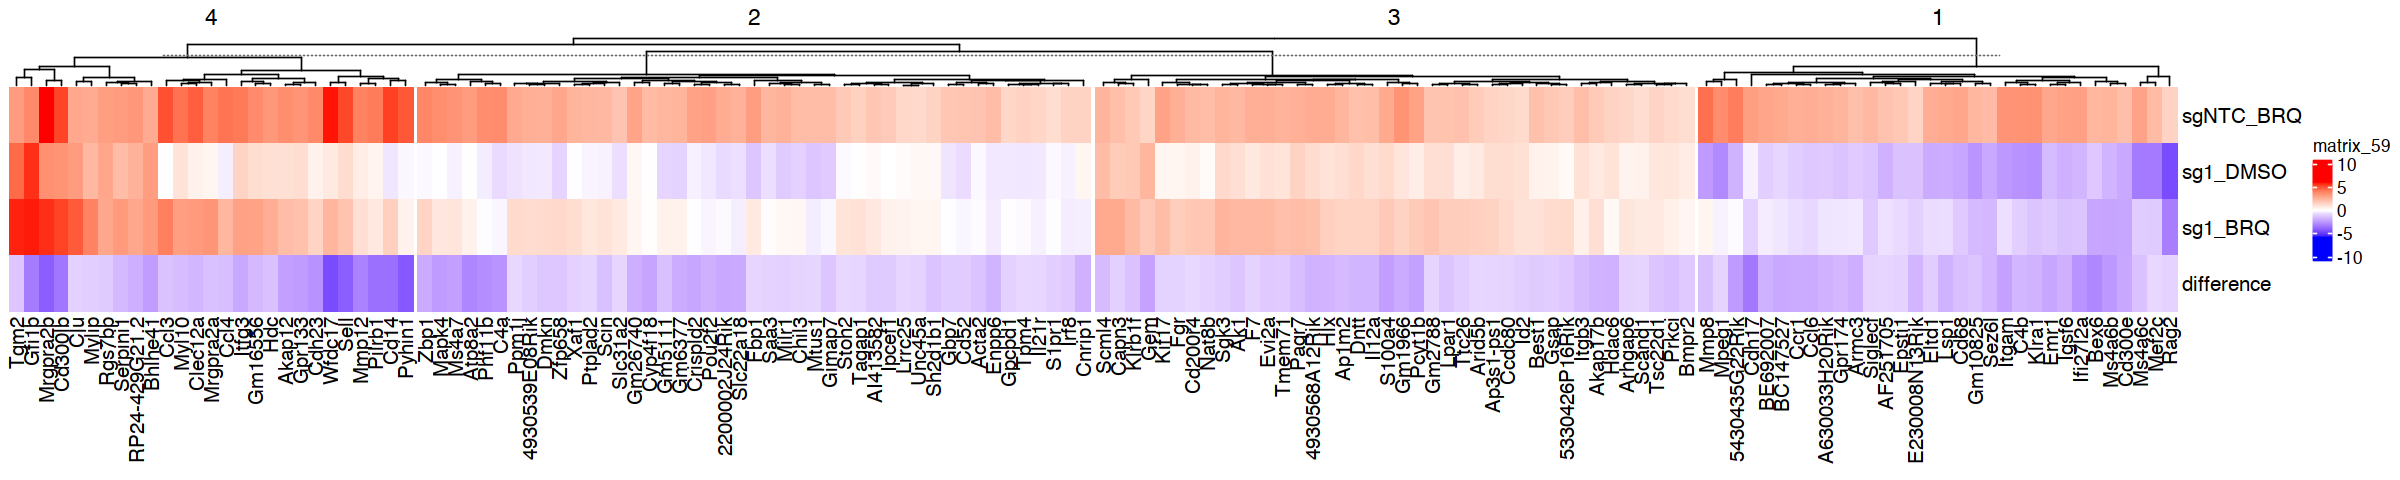

In [272]:
options(repr.plot.width=20, repr.plot.height=4)
cond1 = "sgNTC_BRQ"
dysreg = subset(cond_to_res[[cond1]], adj.P.Val < 0.01 & logFC > 1)$gene  # 630
z = subset(logFCs[dysreg,], difference < -1)  # 144
col_fun = colorRamp2(c(-6, 0, 6), c("blue", "white", "red"))
Heatmap(t(z[,c(2,3,4,7)]), cluster_rows = F, column_km=4, col=col_fun)

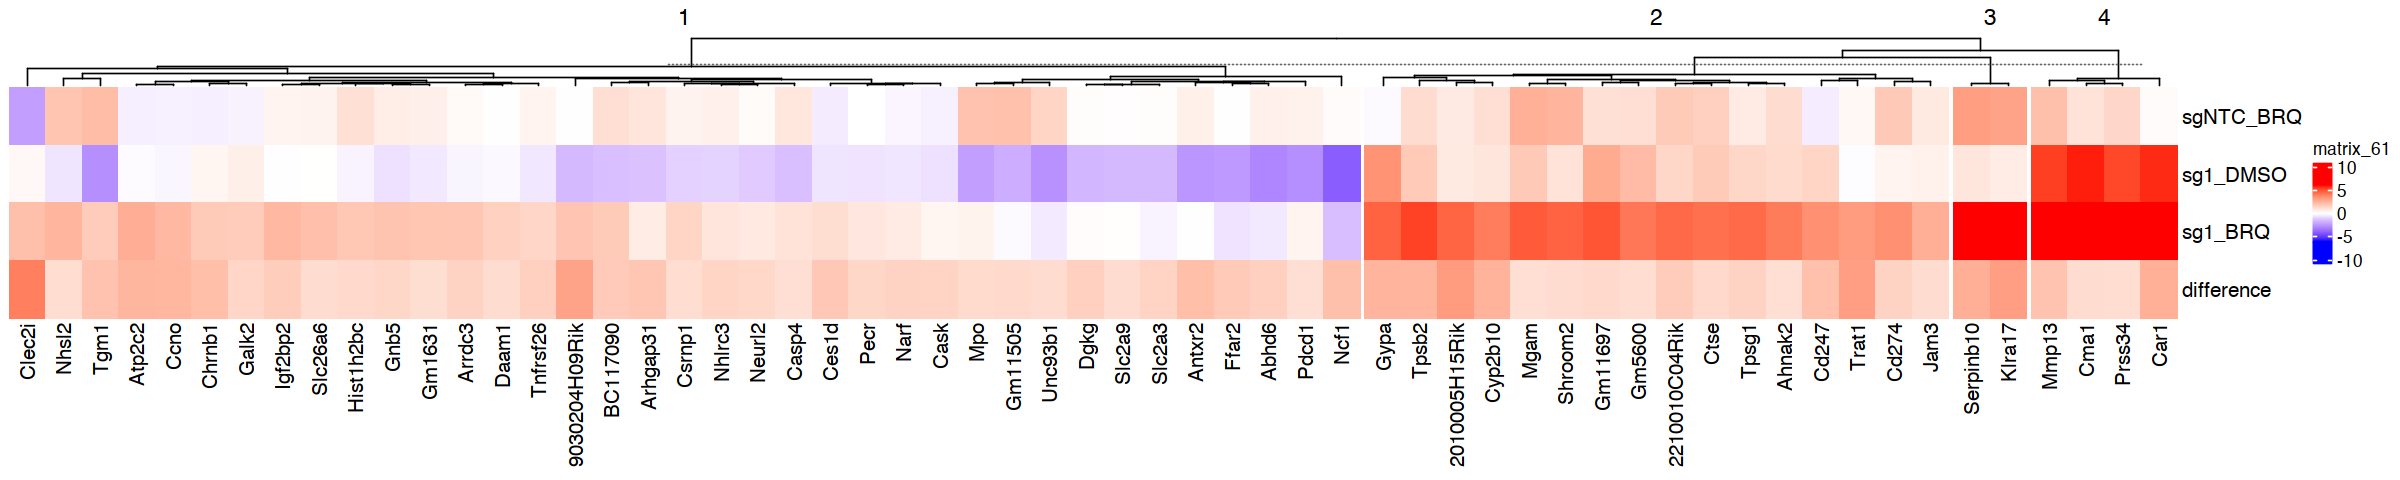

In [279]:
options(repr.plot.width=20, repr.plot.height=4)

cond1 = "sg1_BRQ"
cond2 = "sg1_DMSO"
res <- process_res(makeContrasts(paste("conds", cond1, " - ", "conds", cond2, sep=""), 
                                 levels = colnames(coef(fit))))

dysreg = subset(res, adj.P.Val < 0.01 & logFC > 1)$gene  # 592
z = subset(logFCs[dysreg,], difference > 1)  # 59
col_fun = colorRamp2(c(-6, 0, 6), c("blue", "white", "red"))
Heatmap(t(z[,c(2,3,4,7)]), cluster_rows = F, column_km=4, col=col_fun)

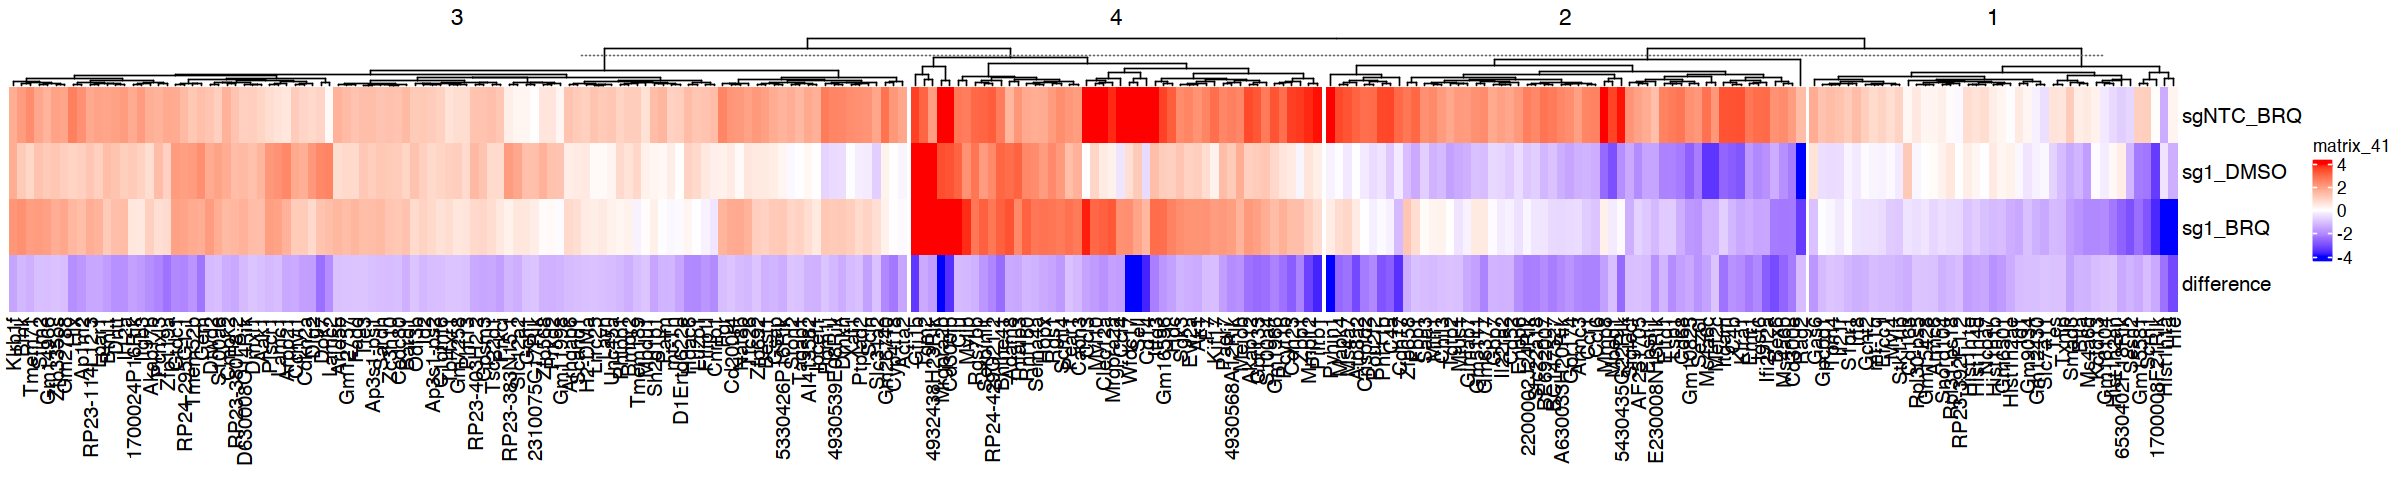

In [232]:
options(repr.plot.width=20, repr.plot.height=4)
z = logFCs[rownames(subset(coeffs, interaction < -1)),]
col_fun = colorRamp2(c(-4, 0, 4), c("blue", "white", "red"))
Heatmap(t(z[,c(2,3,4,7)]), cluster_rows = F, column_km=4, col=col_fun)

Warning message:
"The input is a data frame, convert it to a matrix."


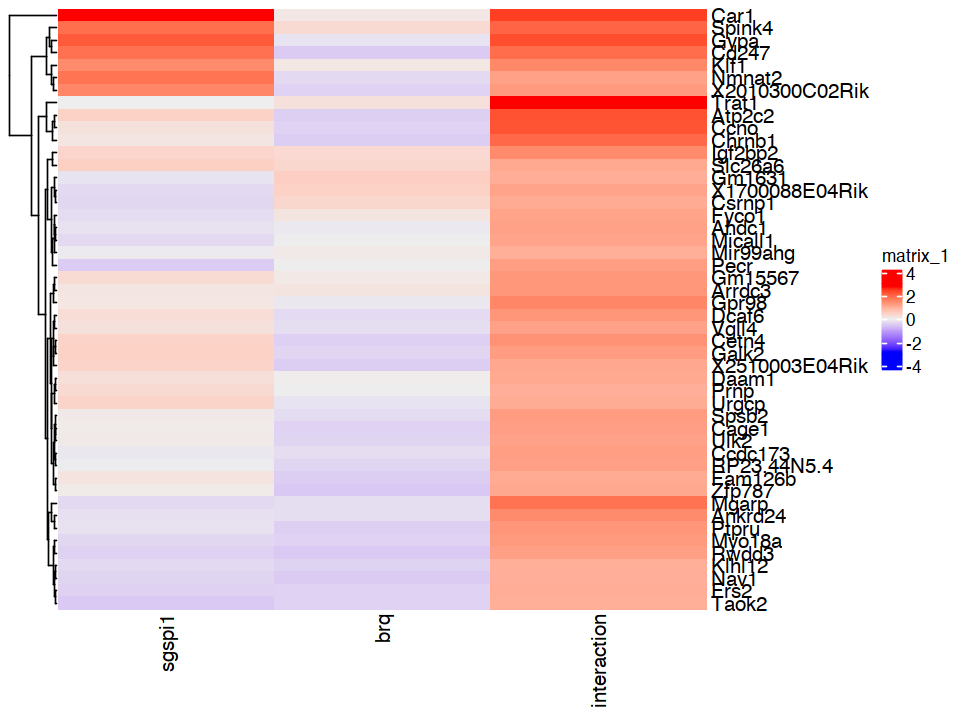

In [77]:
# up in sgspi1, no chg with brq, no interaction  100
a = subset(coeffs, sgspi1 > 1 & abs(brq) < 0.5 & abs(interaction) < 0.5)

# no chg with sgspi1, up in brq, no interaction  010
b = subset(coeffs, abs(sgspi1) < 0.5 & brq > 1 & abs(interaction) < 0.5)

# no chg with sgspi1, no chg with brq, but interaction  001
d = subset(coeffs, abs(sgspi1) < 0.5 & abs(brq) < 0.5 & interaction > 1)

# up in sgspi1, up in brq, no interaction  110
e = subset(coeffs, sgspi1 > 1 & brq > 1 & abs(interaction) < 0.5)

# up in sgspi1, up in brq, interaction  111
f = subset(coeffs, sgspi1 > 1 & brq > 1 & interaction > 1)

# no chg with sgspi1, up in brq, interaction  011
g = subset(coeffs, abs(sgspi1) < 0.5 & brq > 1 & interaction > 1)

# up in sgspi1, no chg with brq, interaction  101
h = subset(coeffs, sgspi1 > 1 & abs(brq) < 0.5 & interaction > 1)

# no change with brq, but interaction 
Heatmap(rbind(d, h), cluster_columns=F)